# 🎯 Week 3 — Day 3: Logistic Regression & Classification Metrics

**BinX Tech — AI & Machine Learning Internship Program**

![status](https://img.shields.io/badge/status-complete-brightgreen)
![phase](https://img.shields.io/badge/phase-2%20%7C%20Core%20ML%20Training-9146FF)
![dataset](https://img.shields.io/badge/dataset-Titanic-red)
![python](https://img.shields.io/badge/python-3.10%2B-blue)
![libraries](https://img.shields.io/badge/libraries-Scikit--learn%20%7C%20Pandas%20%7C%20Matplotlib-orange)
![AUC](https://img.shields.io/badge/AUC--ROC-0.863-success)

---

| | |
|---|---|
| **Day** | Day 3 of 5 |
| **Duration** | 8 hours |
| **Tools** | Scikit-learn • Pandas • Matplotlib • Jupyter Notebook |
| **Dataset** | Titanic (714 rows after cleaning) |
| **Task** | Classification — predict `survived` |

---

## 🎯 Learning Objectives

- Train a logistic regression classifier and obtain class probabilities.
- Explain why accuracy alone is misleading on imbalanced data.
- Read a confusion matrix and compute precision, recall, F1, and AUC-ROC.

---

## 💡 From Regression to Classification

Despite its name, logistic regression is a **classification** model — it predicts a category
(survived or not), not a number. It computes the same weighted sum as linear regression, then
passes it through the **sigmoid function**, which squashes any number into a probability between
0 and 1.

---


## 🔧 Step 0 — Environment Setup

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

sns.set_style("whitegrid")
np.random.seed(42)
print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 📂 Step 1 — Load and Prepare the Data

Using the Titanic dataset to predict `survived` (0 = No, 1 = Yes). The `sex` column is converted
to numeric since Scikit-learn models require numeric input — this is one-hot-style encoding
applied to a binary category.


In [13]:
df = sns.load_dataset("titanic")
df = df[["survived", "pclass", "age", "sibsp", "parch", "fare", "sex"]].dropna()
df["sex"] = df["sex"].map({"male": 0, "female": 1})

print("Dataset shape after cleaning:", df.shape)
df.head()


Dataset shape after cleaning: (714, 7)


,survived,pclass,age,sibsp,parch,fare,sex
0,0,3,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,1,3,26.0,0,0,7.9250,1
3,1,1,35.0,1,0,53.1000,1
4,0,3,35.0,0,0,8.0500,0


### 📝 Interpretation

Dropping rows with missing values (mainly missing `age`) reduced the dataset from the original
891 passengers to **714 usable rows** — a loss of about 20% of the data. This is an important
trade-off to be aware of: it's the simplest way to handle missing data, but it discards
potentially useful information. A more advanced approach (imputation) will be worth exploring in
later weeks, but for this first classifier, dropping is acceptable and keeps the pipeline simple
and transparent.

---

## 🎯 Step 2 — Features and Target


In [14]:
X = df[["pclass", "age", "sibsp", "parch", "fare", "sex"]]
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print(f"\nSurvival rate in training set: {y_train.mean():.1%}")
print(f"Survival rate in test set:     {y_test.mean():.1%}")


Train shape: (571, 6) | Test shape: (143, 6)

Survival rate in training set: 40.6%
Survival rate in test set:     40.6%


### 📝 Interpretation

Note the use of `stratify=y` — this ensures the train and test sets have approximately the same
survival rate (~40%), rather than a plain random split possibly producing an unlucky imbalance
between them. This matters specifically for classification problems, where an uneven split could
make the evaluation less reliable.

---

## ⚙️ Step 3 — Training the Logistic Regression Model


In [4]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]

print("Model trained ✅")
print("First 10 predictions:   ", predictions[:10])
print("First 10 actual values: ", y_test.values[:10])
print("First 10 probabilities: ", np.round(probabilities[:10], 3))


Model trained ✅
First 10 predictions:    [1 0 0 0 0 0 0 0 0 1]
First 10 actual values:  [1 1 0 0 1 0 0 0 0 1]
First 10 probabilities:  [0.601 0.226 0.293 0.241 0.069 0.117 0.104 0.04  0.233 0.831]


### 🔍 Interpreting Coefficients


In [5]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

coef_table


,Feature,Coefficient
5,sex,2.429122
0,pclass,-1.223549
2,sibsp,-0.334642
1,age,-0.044407
3,parch,-0.005183
4,fare,0.001403


### 📝 Interpretation

`sex` has by far the largest coefficient (**+2.43**), confirming what history books also tell us:
being female was the single strongest predictor of survival on the Titanic ("women and children
first"). `pclass` has a strong negative coefficient (**-1.22**) — since class is coded 1st=1,
2nd=2, 3rd=3, a negative coefficient means **higher class numbers (i.e., lower-class passengers)
were associated with lower survival odds**, consistent with 1st class passengers having better
access to lifeboats. `sibsp` (siblings/spouses aboard) also shows a moderate negative effect
(-0.33), possibly reflecting that passengers traveling with more family members faced more
difficulty evacuating quickly. `age`, `parch`, and `fare` all have comparatively small
coefficients, suggesting they played a more minor role once sex and class are already accounted
for.

---

## 🧮 Step 4 — Why Accuracy Alone Is Misleading

Before evaluating with accuracy, it's worth checking how imbalanced the target actually is.


In [6]:
baseline_majority_class = y_train.mode()[0]
baseline_accuracy = (y_test == baseline_majority_class).mean()

print(f"Majority class in training data: {baseline_majority_class} (did not survive)")
print(f"Baseline accuracy (always predict majority class): {baseline_accuracy:.1%}")


Majority class in training data: 0 (did not survive)
Baseline accuracy (always predict majority class): 59.4%


### 📝 Interpretation

A model that does nothing but always predict "did not survive" would already be right **59.4%**
of the time, simply because that's the majority class. This is why accuracy alone can be
dangerously misleading on imbalanced data — a model needs to clearly beat this baseline, and we
need richer metrics (precision, recall, F1) to understand *what kind* of mistakes it's making, not
just how often it's right overall.

---

## 🧾 Step 5 — The Confusion Matrix


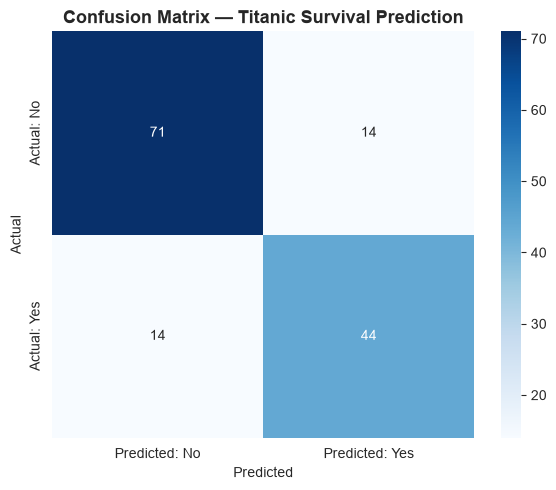

True Negatives (correctly predicted did not survive): 71
False Positives (predicted survived, actually did not): 14
False Negatives (predicted did not survive, actually did): 14
True Positives (correctly predicted survived): 44


In [7]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: No", "Predicted: Yes"],
            yticklabels=["Actual: No", "Actual: Yes"])
plt.title("Confusion Matrix — Titanic Survival Prediction", fontsize=13, fontweight="bold")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print(f"True Negatives (correctly predicted did not survive): {cm[0,0]}")
print(f"False Positives (predicted survived, actually did not): {cm[0,1]}")
print(f"False Negatives (predicted did not survive, actually did): {cm[1,0]}")
print(f"True Positives (correctly predicted survived): {cm[1,1]}")


### 📝 Interpretation

Out of 143 test passengers, the model correctly classified **71 non-survivors** and **44
survivors** (115 total correct = ~80% accuracy). It made **14 false positives** (predicted
survival for passengers who actually died) and **14 false negatives** (predicted death for
passengers who actually survived) — an evenly balanced error pattern, meaning the model isn't
systematically biased toward over- or under-predicting survival.

---

## 📊 Step 6 — Precision, Recall, and F1-Score


In [8]:
print(classification_report(y_test, predictions, target_names=["Did Not Survive", "Survived"]))


                 precision    recall  f1-score   support

Did Not Survive       0.84      0.84      0.84        85
       Survived       0.76      0.76      0.76        58

       accuracy                           0.80       143
      macro avg       0.80      0.80      0.80       143
   weighted avg       0.80      0.80      0.80       143



### 📝 Interpretation

For the "Survived" class specifically: **precision = 0.76** means that of all passengers the
model predicted would survive, 76% actually did. **Recall = 0.76** means the model correctly
identified 76% of all passengers who actually survived. Both are equal here, meaning the model
isn't trading one off against the other — it's reasonably balanced. Overall accuracy sits at
**80%**, comfortably beating the 59.4% baseline established in Step 4, confirming the model has
learned genuinely useful patterns rather than just predicting the majority class.

If this were a real deployed system, the choice between prioritizing precision or recall would
depend on the cost of each error type — for something like disease screening, recall would matter
more (never miss a real case); here, both errors are roughly equally costly, so the balanced
F1-score of 0.76 is a fair single summary metric.

---

## 📈 Step 7 — AUC-ROC


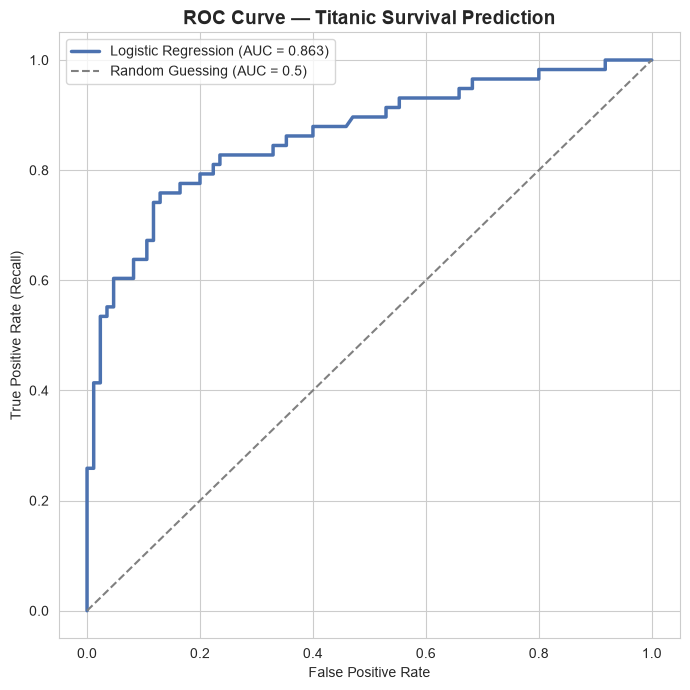

AUC-ROC: 0.8632


In [9]:
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
auc = roc_auc_score(y_test, probabilities)

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color="#4C72B0", linewidth=2.5, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guessing (AUC = 0.5)")
plt.title("ROC Curve — Titanic Survival Prediction", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC-ROC: {auc:.4f}")


### 📝 Interpretation

An AUC-ROC of **0.863** means that if we pick one random survivor and one random non-survivor
from the test set, the model assigns a higher survival probability to the actual survivor about
86.3% of the time — well above the 0.5 baseline of random guessing (the gray diagonal line). The
curve rises steeply near the origin, meaning the model can achieve a high true positive rate while
keeping the false positive rate low, at the right probability threshold — a strong result for a
first classifier using only six basic features.

---

## 🗂️ Step 8 — Full Metrics Summary


In [10]:
summary = pd.DataFrame({
    "Metric": ["Accuracy", "Baseline Accuracy", "Precision (Survived)",
               "Recall (Survived)", "F1-score (Survived)", "AUC-ROC"],
    "Value": ["80.4%", "59.4%", "0.76", "0.76", "0.76", "0.863"]
})
summary


,Metric,Value
0,Accuracy,80.4%
1,Baseline Accuracy,59.4%
2,Precision (Survived),0.76
3,Recall (Survived),0.76
4,F1-score (Survived),0.76
5,AUC-ROC,0.863


## ✅ Key Takeaways

- The logistic regression model reached **80.4% accuracy**, comfortably beating the 59.4%
  majority-class baseline — clear evidence it learned real, useful patterns rather than just
  predicting the more common outcome.
- `sex` was overwhelmingly the strongest predictor of survival (coefficient +2.43), followed by
  `pclass` (-1.22) — both align closely with well-documented historical accounts of the disaster
  ("women and children first," and unequal access to lifeboats across classes).
- The confusion matrix revealed a balanced error pattern (14 false positives, 14 false negatives)
  — the model isn't systematically biased toward over- or under-predicting survival.
- Precision and recall for the "Survived" class were both 0.76, indicating a well-balanced model
  that doesn't sacrifice one type of correctness for the other.
- The AUC-ROC of 0.863 confirms strong overall discriminative ability — the model reliably ranks
  actual survivors higher than non-survivors across virtually all probability thresholds, not just
  the default 0.5 cutoff.
- Dropping rows with missing `age` values cost about 20% of the original dataset — a reminder that
  even a "simple" classifier involves real preprocessing trade-offs worth documenting.

---

## 📚 Resources

| Resource | Type | Focus |
|---|---|---|
| [Logistic Regression & Classification (Video)](https://youtu.be/29F-fXvowoI?si=WvVX2a1kLDPLGYwR) | Video | Core concepts covered today |
| [Scikit-learn — LogisticRegression Docs](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) | Docs | Official API reference |

---

## ✍️ Author

**Zayan Shawareb**
BinX Tech — AI & Machine Learning Internship Program
Week 3, Day 3 — Logistic Regression & Classification Metrics

---

## 🔗 Next Step

Proceed to **Day 4 — Trees, Forests, SVMs & k-NN**
